# Проект для прогноза сердечно-сосудистых заболеваний

Требуется разобрать набор данных, представленных в файле cardio_train.csv, создать нейронную сеть для предсказания заболеваний, создать несколько моделей (или одну). Сравнить результаты и провести аналитику

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from datetime import datetime, timedelta
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from tensorflow import keras
%matplotlib inline

## Загрузка данных

In [2]:
df = pd.read_csv('cardio_train.csv', sep=';')

In [3]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


# id, Номер пациента, Уникальный признак, целочисленное значение
### age, Возраст, Объективный признак, целочисленное значение
_______________________________________________________________
### height, Рост, Объективный признак, целочисленное значение (см)
_______________________________________________________________
### weight, Вес, Объективный признак, число с плавающей точкой (кг)

_______________________________________________________________
### gender, Пол, Объективный признак, категориальный код: 1 - женщина, 2 - мужчина

_______________________________________________________________
### ap_hi, Систолическое артериальное давление, Характеристика обследования, целочисленное значение

_______________________________________________________________

### ap_lo, Диастолическое артериальное давление, Характеристика обследования, целочисленное значение

_______________________________________________________________
### cholesterol, Холестерин, Характеристика обследования, категориальный код: 1 - нормальный, 2 - выше нормы, 3 - значительно выше нормы
_______________________________________________________________
### gluc, Глюкоза, Характеристика обследования, категориальный код: 1 - нормальный, 2 - выше нормы, 3 - значительно выше нормы
_______________________________________________________________
### smoke, Курение, Субъективная характеристика, бинарный: 0 - не курит, 1 - курит
_______________________________________________________________
### alco, Употребление алкоголя, Субъективная характеристика, бинарный: 0 - не употребляет, 1 - употребляет
_______________________________________________________________
### active, Физическая активность, Субъективная характеристика, бинарный: 0 - низкая, 1 - высокая
_______________________________________________________________
### cardio, Наличие сердечно-сосудистых заболеваний, Целевая переменная, бинарный: 0 - отсутствуют, 1 - присутствуют
_______________________________________________________________
_______________________________________________________________

Систолическое артериальное давление - это давление, которое кровь оказывает на стенки артерий в момент, когда сердце сокращается и выбрасывает кровь в сосуды.
_______________________________________________________________
Пределы систолического артериального давления:
- минимальный предел: 50-60 мм рт. ст.;
- максимальный предел:: 250-300 мм рт. ст)

_______________________________________________________________
_______________________________________________________________

Диастолическое артериальное давление(ДАД), или «нижнее» давление, - это показатель, отражающий давление крови на стенки артерий в момент расслабления и наполнения сердца кровью между ударами.

_______________________________________________________________

Пределы диастолического артериального давления:
- 40-45 мм рт. ст.;
- 130-150 мм рт. ст.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
df['age_year'] = df['age'].apply(lambda x: (datetime(1, 1, 1) + timedelta(x)).year)

In [6]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_year
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700,53.804429
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003,6.762354
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,49.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,54.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,59.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


После небольшого анализа, была замечена анамалия в систолическом и диастолическом артериальное давление.

## Анализ исходного датасета

In [7]:
df.hist(figsize = (15,10), bins = 50);

In [8]:
sns.displot(df['age_year']);

In [9]:
sns.displot(df['weight']);

In [10]:
sns.displot(df['height']);

In [11]:
anamalies = df[(df['ap_hi'] <= 70) | (df['ap_hi'] >= 200)].shape[0]
percentage_anamalies = anamalies / df.shape[0]
print(f'Количество записей, у которых САД имеет меньше 70 или больше 200: {anamalies}({percentage_anamalies}).')

Количество записей, у которых САД имеет меньше 70 или больше 200: 418(0.005971428571428571).


In [12]:
plt.boxplot(x='ap_hi', data=df);

In [13]:
anamalies = df[(df['ap_lo'] <= 50) | (df['ap_lo'] > 140)].shape[0]
percentage_anamalies = anamalies / df.shape[0]
print(f'Количество записей, у которых ДАД имеет меньше 50 или больше 140: {anamalies}({percentage_anamalies}).')

Количество записей, у которых ДАД имеет меньше 50 или больше 140: 1119(0.015985714285714287).


In [14]:
plt.boxplot(x='ap_lo', data=df);

In [15]:
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

In [16]:
plt.bar(x='cardio', height=20, data=df)

<BarContainer object of 70000 artists>

In [17]:
sns.pairplot(df)

In [18]:
plt.figure(figsize=(15, 15)) 
sns.heatmap(df.corr(), square=True, annot=True, linewidths=.5)

<Axes: >

По итогам проведённого анализа датасета можно выявить следующии высказывания:

В столбцах, отвечающих за систолическое и диастолическое давление, зафиксированы редкие некорректные значения (менее 0.1% от общего числа наблюдений). Ввиду их малочисленности данные записи, с аномальными данными, будут исключены.

Обнаружена статистическая связь между ростом пациентов и их полом.

Показатели глюкозы и холестерина проявляют взаимное влияние.

Существует зависимость между факторами курения и употребления алкоголя.

## Предварительная обработка датасета;

In [19]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_year
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,51
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,56
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,52
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,49
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,53
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,62
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,53
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,62


In [20]:
# Удаление аномальных данных из признака САД
df = df[(df['ap_hi'] > 70) & (df['ap_hi'] < 200)]

In [21]:
# Удаление аномальных данных из признака ДАД
df = df[(df['ap_lo'] > 50) & (df['ap_lo'] < 140)]

In [22]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_year
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,51
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,56
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,52
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,49
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,53
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,62
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,53
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,62


In [68]:
# Повторный просмотр тепловой карты, после обработки данных
plt.figure(figsize=(15, 15)) 
sns.heatmap(df.corr(), square=True, annot=True, linewidths=.5)

<Axes: >

## Обучение моделей

В качестве моделей для обучения, выбираем:
- для классификации: ближайшие соседи и Гауссовский;
- для ансамблевых методов: рандомный лес и градиетный бустинг;
- нейросеть просто нейросеть.

In [24]:
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_year
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,51
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,56
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,52
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,49
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0,53
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1,62
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1,53
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1,62


In [25]:
X = df.drop(['cardio', 'age', 'id'], axis=1)
y= df['cardio']

In [26]:
# Разделение данных на тренировочную и тестувую
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44, stratify=y)

In [27]:
X_train.shape, X_test.shape

((47947, 11), (20549, 11))

In [28]:
y_train.shape, y_test.shape

((47947,), (20549,))

### Классифкация(Ближайшие соседи и Гауссовский)

### Ближайшие соседи

In [29]:
%%time
# Настройка гиперпараметров
param_grid = {'n_neighbors': [i for i in range(1, 30)]}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(estimator=knn, param_grid=param_grid, cv=5, n_jobs=10)
grid_search.fit(X_train, y_train)
print("Best Parameters: ", grid_search.best_params_)

Best Parameters:  {'n_neighbors': 28}
CPU times: total: 2.03 s
Wall time: 45.4 s


In [30]:
n_neighbors = 28

In [31]:
model_knn = KNeighborsClassifier(n_neighbors=n_neighbors, n_jobs=10)

In [32]:
model_knn.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=10, n_neighbors=28)

In [33]:
model_knn_pred = model_knn.predict(X_test)

In [34]:
print(classification_report(y_test, model_knn_pred))

              precision    recall  f1-score   support

           0       0.70      0.78      0.74     10395
           1       0.75      0.65      0.70     10154

    accuracy                           0.72     20549
   macro avg       0.72      0.72      0.72     20549
weighted avg       0.72      0.72      0.72     20549



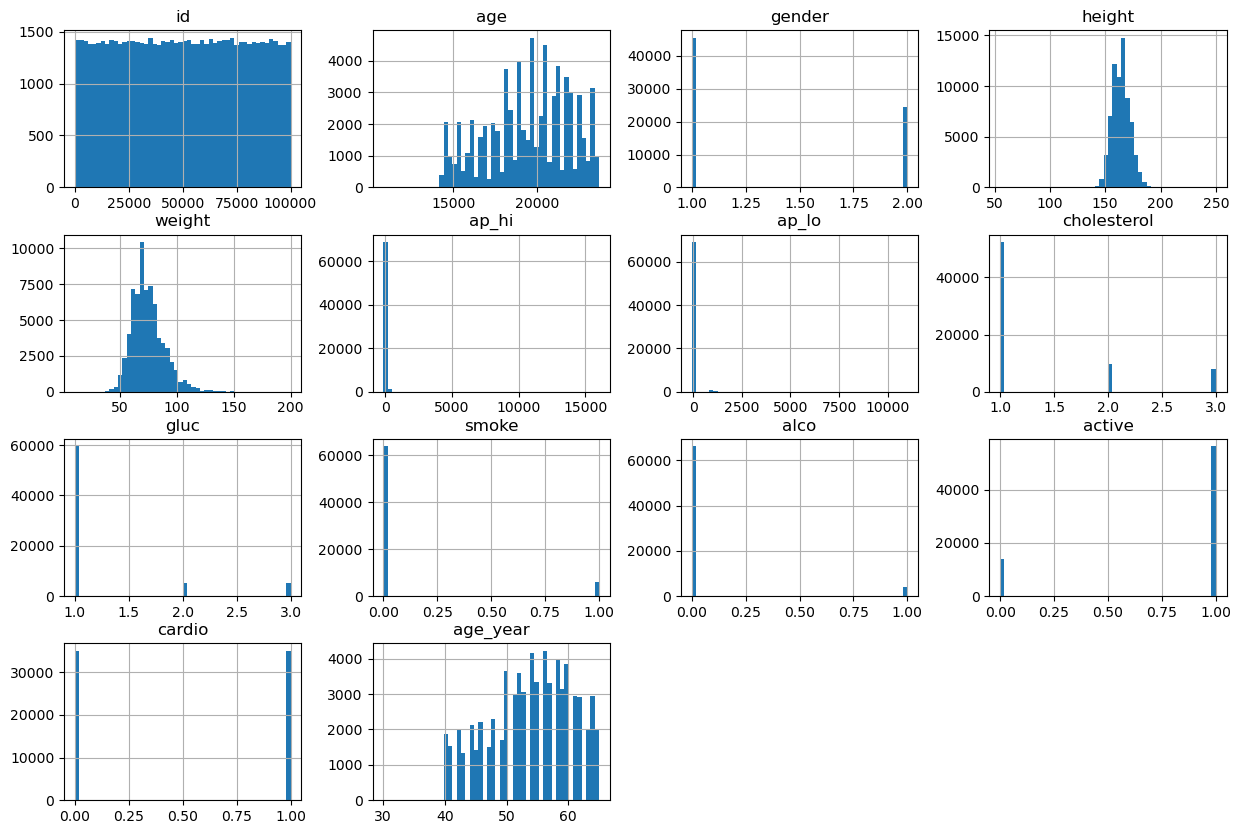

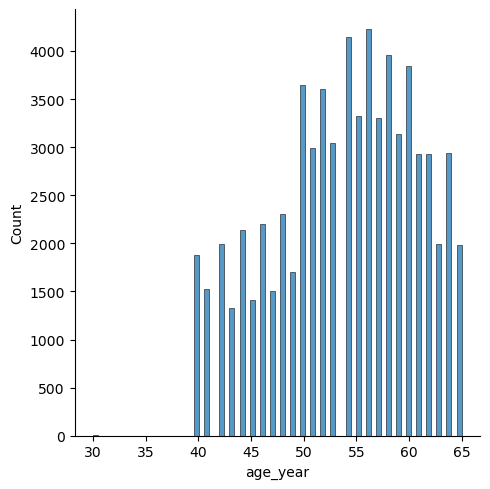

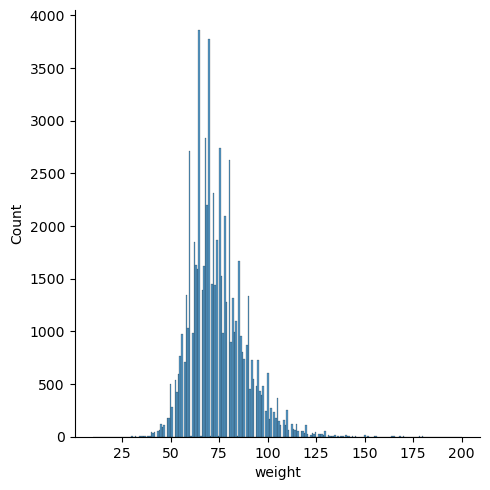

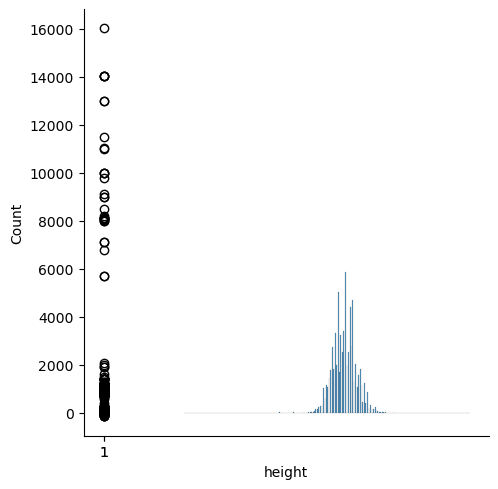

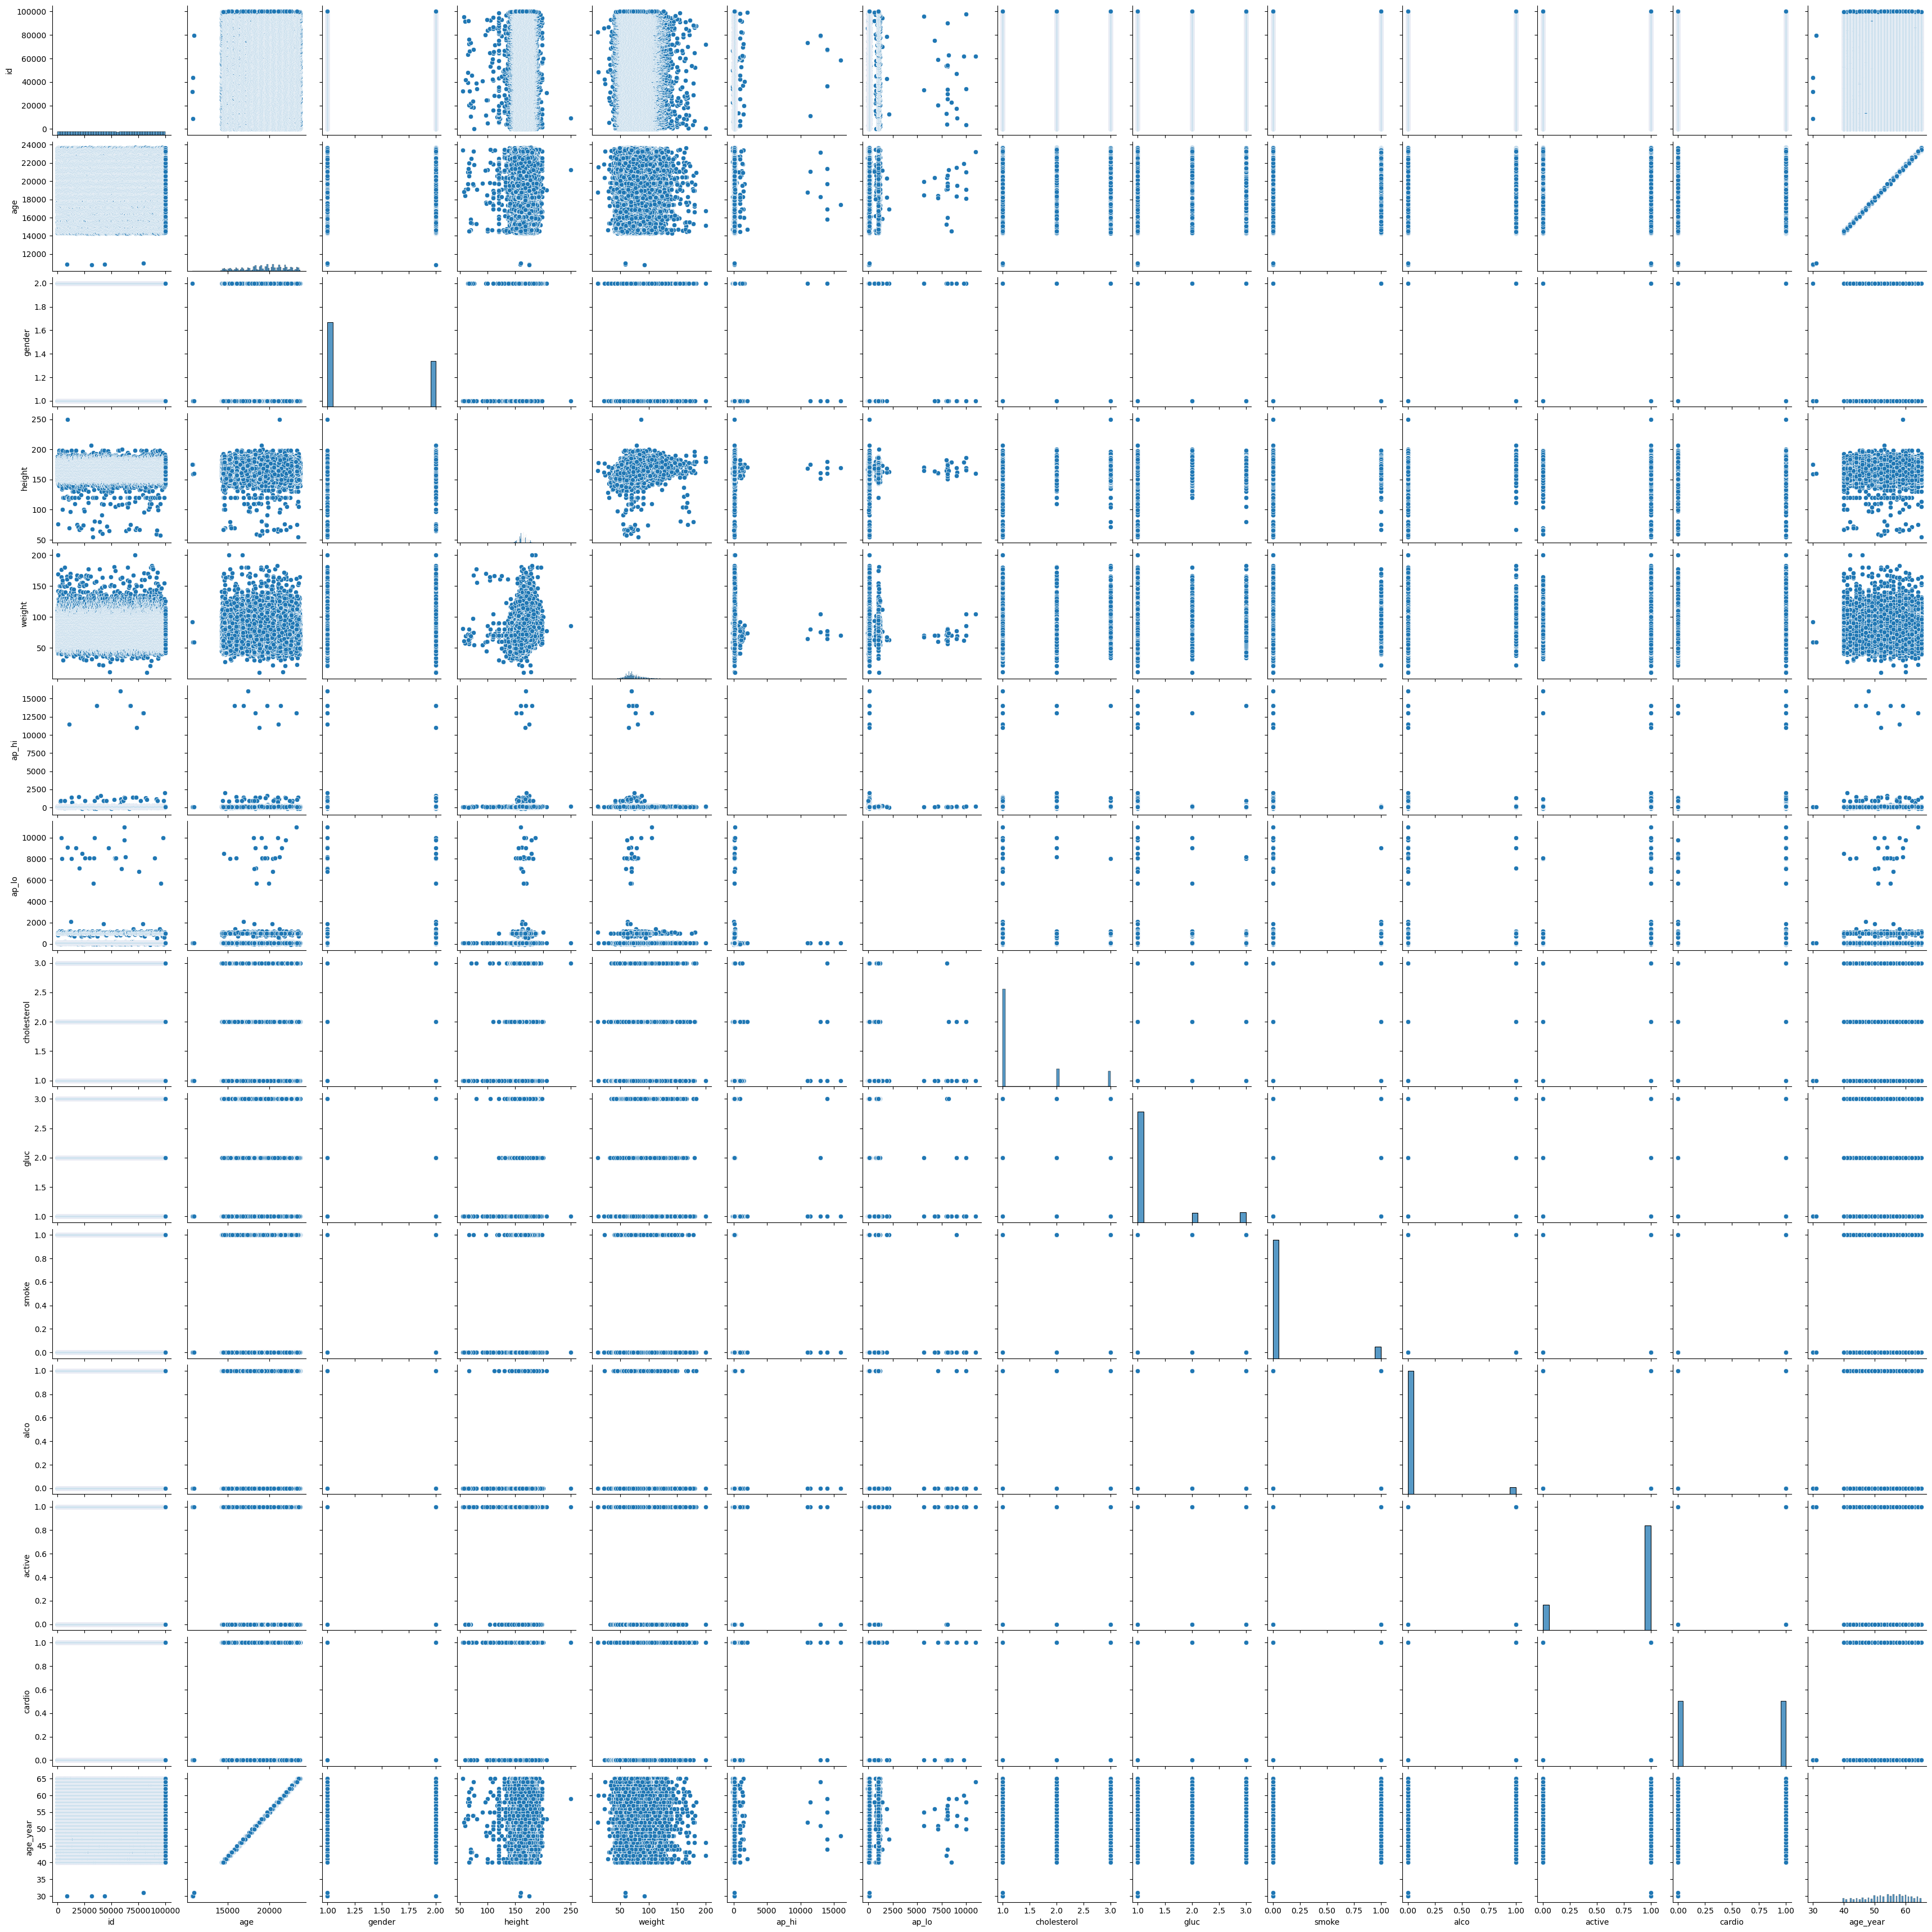

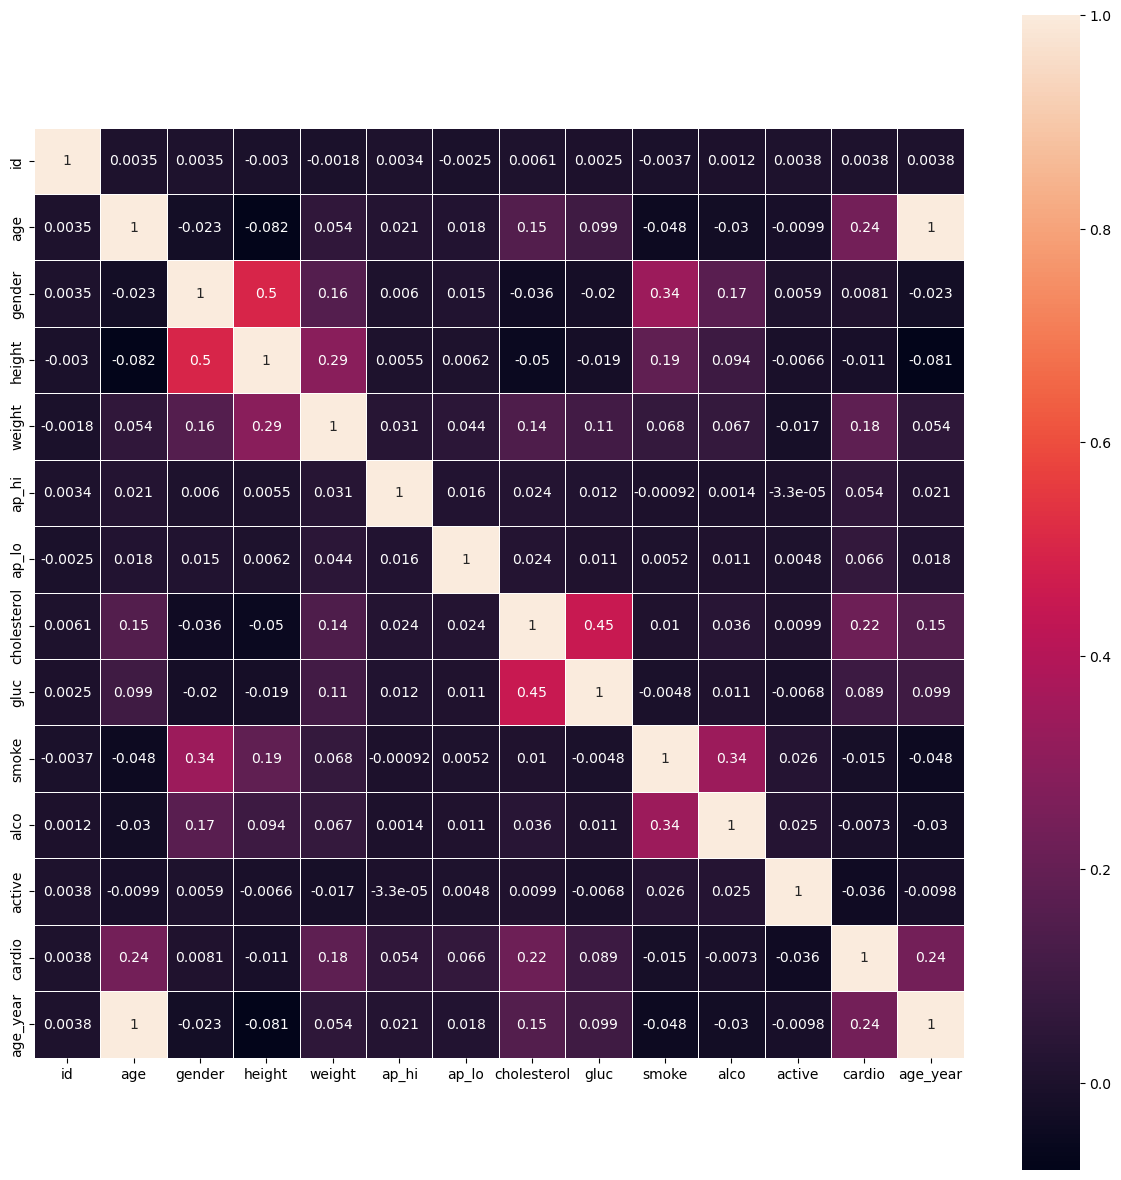

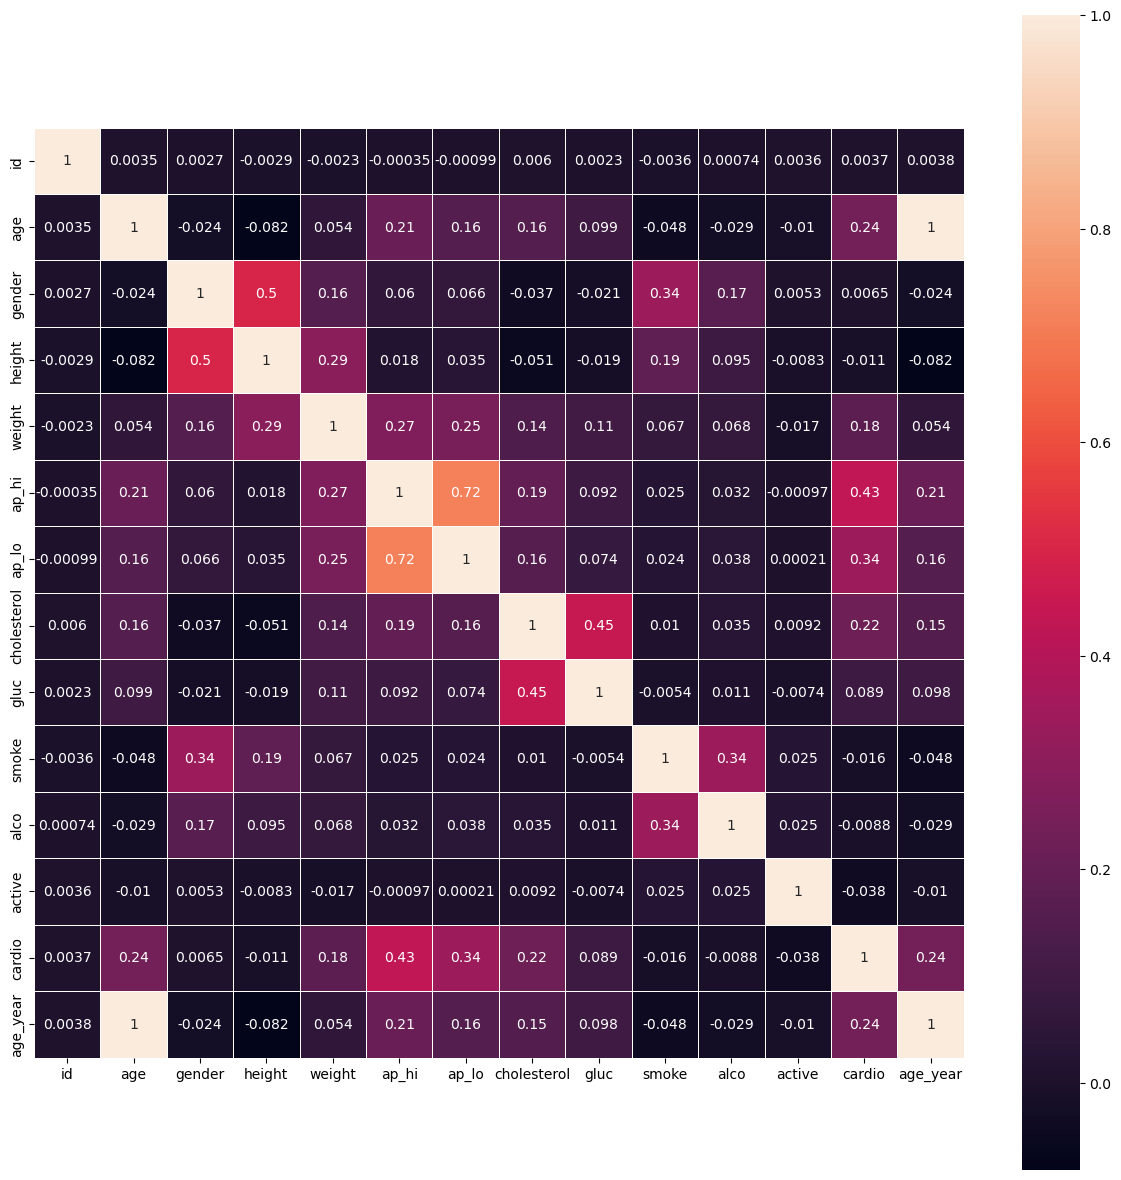

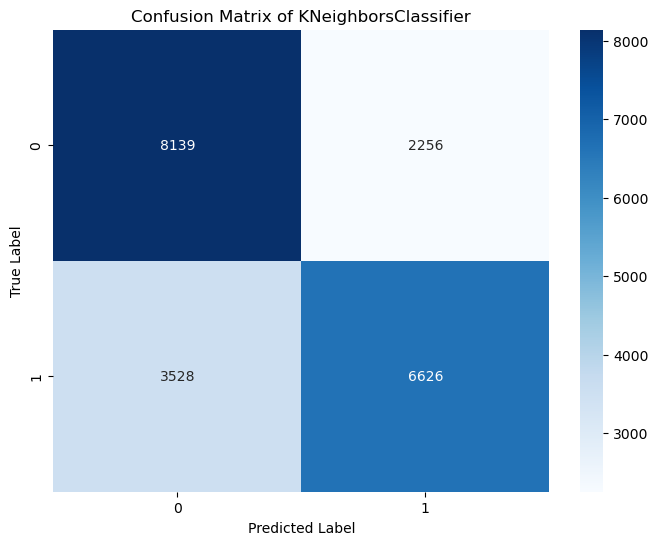

In [35]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, model_knn_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of KNeighborsClassifier')
plt.show()

### Гауссовский

In [36]:
model_gnb = GaussianNB()

In [37]:
model_gnb.fit(X_train, y_train)

GaussianNB()

In [38]:
model_gnb_pred = model_gnb.predict(X_test)

In [39]:
print(classification_report(y_test, model_gnb_pred))

              precision    recall  f1-score   support

           0       0.68      0.81      0.74     10395
           1       0.76      0.62      0.68     10154

    accuracy                           0.71     20549
   macro avg       0.72      0.71      0.71     20549
weighted avg       0.72      0.71      0.71     20549



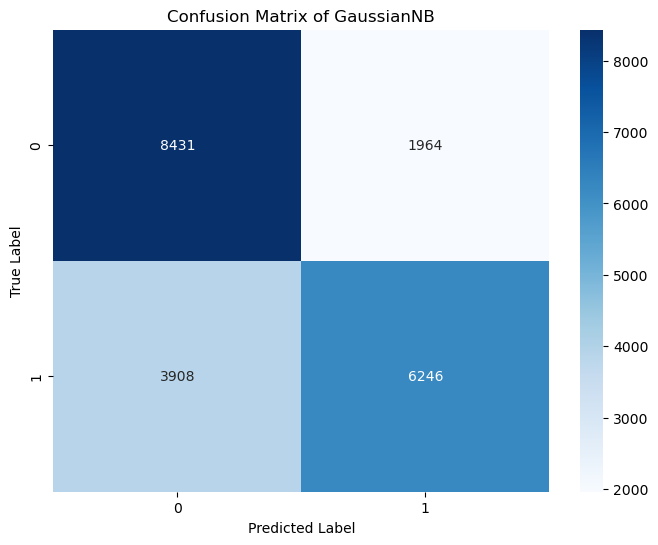

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, model_gnb_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of GaussianNB')
plt.show()

## Краткий вывод по классификации

После обучения моделей, они показали схожий результат, который примерно составил 0.715 по метрике f1_score. Результат показали хороший, но далёк от идеала.

## Ансамблевый метод(рандомный лес и градиетный бустинг)

## Рандомный лес

In [41]:
%%time

# Настройка гиперпараметров
param_grid = {'n_estimators': [i for i in range(100, 150)], 'max_depth' : [i for i in range(1, 8)]}

rfc = RandomForestClassifier(random_state=33)

grid_search = GridSearchCV(estimator=rfc, param_grid=param_grid, cv=5, n_jobs=10)
grid_search.fit(X_train, y_train)
print("Best Parameters: ", grid_search.best_params_)

Best Parameters:  {'max_depth': 7, 'n_estimators': 143}
CPU times: total: 27 s
Wall time: 9min 13s


In [42]:
n_estimators = 114
max_depth = 7

In [43]:
model_rfc = RandomForestClassifier(random_state=33, n_estimators=n_estimators, max_depth=max_depth)

In [44]:
model_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, n_estimators=114, random_state=33)

In [45]:
model_rfc_pred = model_rfc.predict(X_test)

In [46]:
print(classification_report(y_test, model_rfc_pred))

              precision    recall  f1-score   support

           0       0.71      0.79      0.75     10395
           1       0.76      0.66      0.71     10154

    accuracy                           0.73     20549
   macro avg       0.73      0.73      0.73     20549
weighted avg       0.73      0.73      0.73     20549



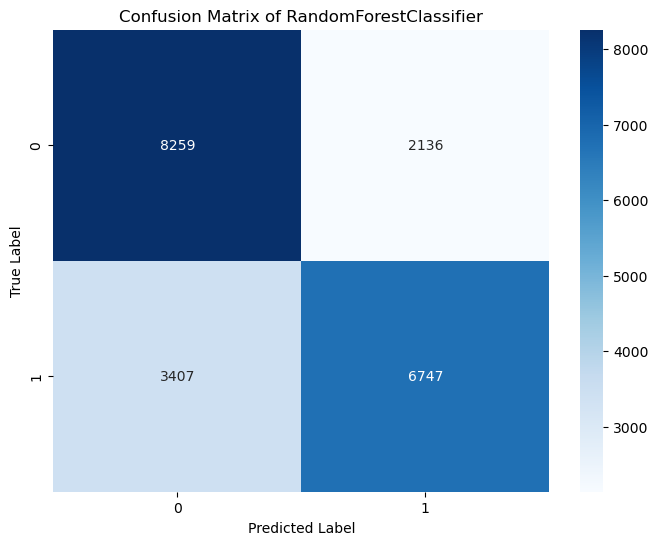

In [47]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, model_rfc_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of RandomForestClassifier')
plt.show()

## Градиетный бустинг

In [48]:
%%time

# Настройка гиперпараметров
param_grid = {'n_estimators': [i for i in range(100, 150)], 'learning_rate': [i for i in (0.1, 0.4, 0.1)]}

gbc = GradientBoostingClassifier(random_state=33)

grid_search = GridSearchCV(estimator=gbc, param_grid=param_grid, cv=5, n_jobs=10)
grid_search.fit(X_train, y_train)
print("Best Parameters: ", grid_search.best_params_)

Best Parameters:  {'learning_rate': 0.1, 'n_estimators': 138}
CPU times: total: 15.4 s
Wall time: 8min 28s


In [49]:
n_estimators = 138
learning_rate = 0.1

In [50]:
model_gbc = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, random_state=33)

In [51]:
model_gbc.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=138, random_state=33)

In [52]:
model_gbc_pred = model_gbc.predict(X_test)

In [53]:
print(classification_report(y_test, model_gbc_pred))

              precision    recall  f1-score   support

           0       0.72      0.78      0.75     10395
           1       0.75      0.70      0.72     10154

    accuracy                           0.74     20549
   macro avg       0.74      0.74      0.74     20549
weighted avg       0.74      0.74      0.74     20549



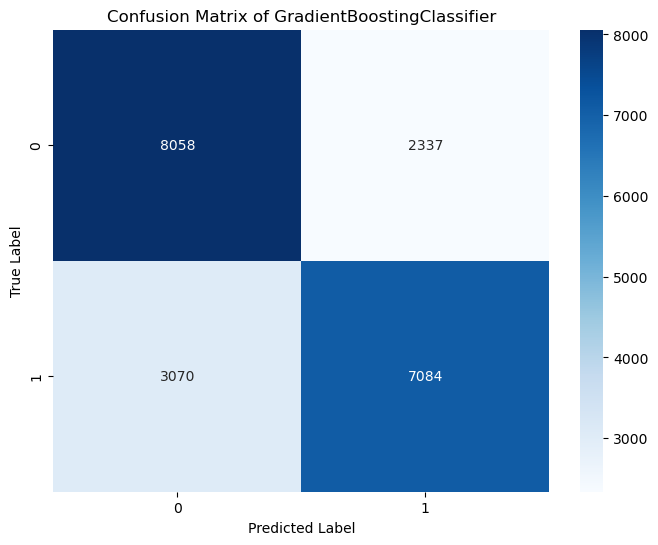

In [54]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, model_gbc_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of GradientBoostingClassifier')
plt.show()

## Краткий вывод по ансамблевым методам

После обучение ансамблевых методов, было выявленно, что модели получились схожи с моделями классификации. Ансамблевые методы показали чуть лучше результат, но не прям сильно лучше. Примерная оценка по метрики f1-score составила: 0.73

## Нейросеть

In [55]:
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

In [56]:
model_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=(11,), activation='leaky_relu', name='input'),
    tf.keras.layers.Dense(10, activation='leaky_relu', name='hidden_1'),
    tf.keras.layers.Dense(10, activation='leaky_relu', name='hidden_2'),
    tf.keras.layers.Dense(1, activation='sigmoid', name='output'),
])

In [57]:
model_nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [58]:
print(model_nn.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input (Dense)               (None, 10)                120       
                                                                 
 hidden_1 (Dense)            (None, 10)                110       
                                                                 
 hidden_2 (Dense)            (None, 10)                110       
                                                                 
 output (Dense)              (None, 1)                 11        
                                                                 
Total params: 351
Trainable params: 351
Non-trainable params: 0
_________________________________________________________________
None


In [59]:
History = model_nn.fit(X_train, y_train, epochs=1000, batch_size=16, validation_data=(X_test, y_test),callbacks = [early_stop])

Epoch 1/1000
2997/2997 [==============================] - 7s 2ms/step - loss: 0.6520 - accuracy: 0.6614 - val_loss: 0.5727 - val_accuracy: 0.7122
Epoch 2/1000
2997/2997 [==============================] - 6s 2ms/step - loss: 0.5916 - accuracy: 0.6953 - val_loss: 0.5918 - val_accuracy: 0.6881
Epoch 3/1000
2997/2997 [==============================] - 6s 2ms/step - loss: 0.5846 - accuracy: 0.7010 - val_loss: 0.6141 - val_accuracy: 0.6951
Epoch 4/1000
2997/2997 [==============================] - 6s 2ms/step - loss: 0.5779 - accuracy: 0.7057 - val_loss: 0.6132 - val_accuracy: 0.6536
Epoch 5/1000
2997/2997 [==============================] - 6s 2ms/step - loss: 0.5757 - accuracy: 0.7074 - val_loss: 0.5708 - val_accuracy: 0.7153
Epoch 6/1000
2997/2997 [==============================] - 6s 2ms/step - loss: 0.5740 - accuracy: 0.7086 - val_loss: 0.5646 - val_accuracy: 0.7161
Epoch 7/1000
2997/2997 [==============================] - 6s 2ms/step - loss: 0.5718 - accuracy: 0.7095 - val_loss: 0.5635 -

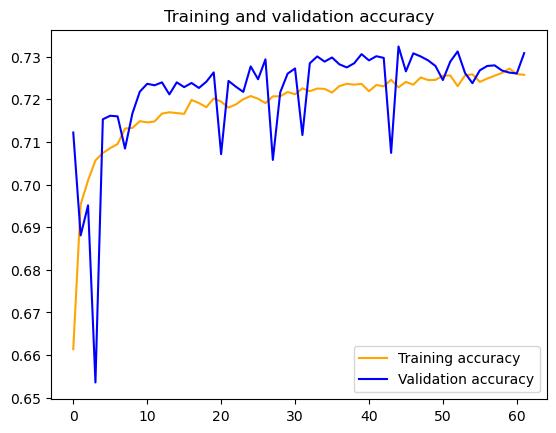

<Figure size 640x480 with 0 Axes>

In [60]:
acc = History.history['accuracy']
val_acc = History.history['val_accuracy']
loss = History.history['loss']
val_loss = History.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'orange', label='Training accuracy')
plt.plot(epochs, val_acc, 'blue', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()


plt.show()

In [61]:
model_nn_pred = model_nn.predict(X_test)

In [62]:
model_nn_pred

array([[0.7030291 ],
       [0.4696479 ],
       [0.8818705 ],
       ...,
       [0.1662263 ],
       [0.55172324],
       [0.79720527]], dtype=float32)

In [63]:
model_nn_pred = (model_nn_pred.flatten() >= 0.5).astype(int)

In [64]:
model_nn_pred

array([1, 0, 1, ..., 0, 1, 1])

In [65]:
print(classification_report(y_test, model_nn_pred))

              precision    recall  f1-score   support

           0       0.74      0.72      0.73     10395
           1       0.72      0.74      0.73     10154

    accuracy                           0.73     20549
   macro avg       0.73      0.73      0.73     20549
weighted avg       0.73      0.73      0.73     20549



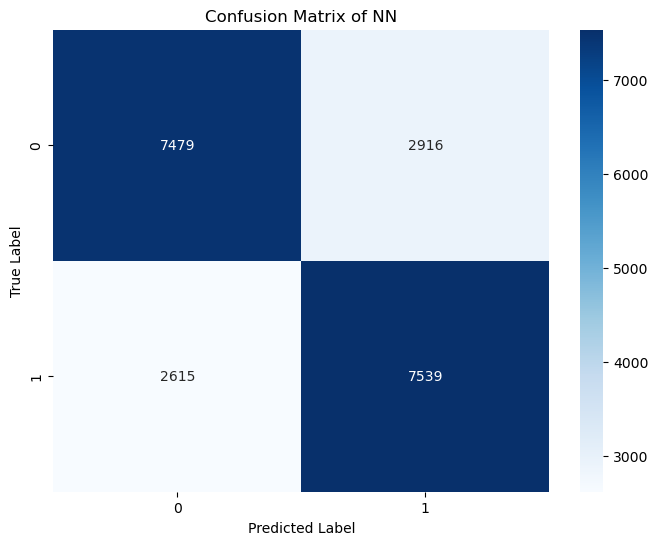

In [66]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, model_nn_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix of NN')
plt.show()

# Нейросеть

После обучения нейронной сети на 62 поколении, мы получаем очень хороший результат для точности - 0.71. Данный результат показывает, что нейросеть, в сравнении с обычными моделями, требует большего количества данных. По моему мнению 70 тысяч недостаточно данных для нейронной сети. В следущий раз стоит искать более большой набор данных.

## Заключение
Данный набор данных показывает очень важную проблему в нынешнее время, так как у очень большего количества людей сейчас высокий уровень холестирина, очень много людей курит, а чаще всего если курит то и пьет. В связи с таким положением вещей, у многих развиваются самые разные болезни сердечно-сосудистой системы. Поэтому я считаю, что такие нейронки и модели очень сильно помогут борться с нынешним положением дел в мире (бургеры и американцы - зло)

Подводя итоги по проделанной работе, были выполнены все поставленные задачи. Датасет был загружен, изучен и проанализирован. Были анмольные данные в признаках ap_hi и ap_lo. Была замечена зависимость у признаков:
- gluc и cholesterol;
- smoke и alko.

Что ещё раз доказывает, что люди, курящие и пьющие, подверженны ССЗ в разы чаще чем остальные

После удаление аномальных значений у признаков ap_hi и ap_lo, между ними появилась зависимость.

Модели, представленные к обучению, как обычные, так и ансамблевые, имеют схожий результат с нейронкой, примерно 0.7 точности, что, я считаю, ещё раз доказывает мою теорию о том, что в наборе данных слишком мало записей